<a href="https://colab.research.google.com/github/anubha06/uncertainty-aware-portfolio-optimization/blob/main/01_setup_and_data_collection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install required libraries
!pip install yfinance --quiet

# Import libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

print("Libraries installed and imported successfully.")

Libraries installed and imported successfully.


In [ ]:
# Create project folders
folders = ["data", "plots", "reports"]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project folders created successfully.")
print("Folders:", folders)

Project folders created successfully.
Folders: ['data', 'plots', 'reports']


In [ ]:
# Larger stock universe for resume-grade version

tickers = [
    # Technology
    "AAPL", "MSFT", "GOOGL", "AMZN", "META", "NVDA", "AMD", "INTC", "ORCL", "CRM",
    "ADBE", "CSCO", "QCOM", "IBM", "TXN",

    # Financials
    "JPM", "BAC", "WFC", "GS", "MS", "C", "AXP", "BLK", "SCHW", "USB",

    # Healthcare
    "JNJ", "UNH", "PFE", "MRK", "ABBV", "TMO", "ABT", "LLY", "BMY", "CVS",

    # Consumer Defensive
    "PG", "KO", "PEP", "WMT", "COST", "MDLZ", "CL", "KMB", "GIS",

    # Consumer Cyclical
    "TSLA", "HD", "LOW", "NKE", "SBUX", "MCD", "TGT", "BKNG", "TJX", "GM",

    # Energy
    "XOM", "CVX", "COP", "SLB", "EOG", "MPC", "PSX", "VLO", "OXY", "HAL",

    # Industrials
    "BA", "CAT", "GE", "HON", "UPS", "RTX", "LMT", "DE", "MMM", "FDX",

    # Communication
    "NFLX", "DIS", "CMCSA", "VZ", "T", "TMUS", "EA",  "FOXA", "CHTR",

    # Utilities / Real Estate / Materials
    "NEE", "DUK", "SO", "AEP", "D", "AMT", "PLD", "SPG", "LIN", "APD",

    # Benchmark
    "SPY"
]

start_date = "2015-01-01"
end_date = "2024-12-31"

In [ ]:
# Download larger stock dataset
data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    group_by="column",
    progress=True
)

# Extract adjusted close prices
prices = data["Close"]

# Remove columns with too many missing values
missing_ratio = prices.isna().mean()
valid_tickers = missing_ratio[missing_ratio < 0.10].index.tolist()

prices = prices[valid_tickers]

# Fill small missing gaps
prices = prices.ffill().bfill()

# Save prices
prices.to_csv("data/prices_large.csv")

print("Large price dataset saved as data/prices_large.csv")
print("Number of stocks downloaded:", prices.shape[1])
print("Number of trading days:", prices.shape[0])

prices.head()

[*********************100%***********************]  94 of 94 completed


Large price dataset saved as data/prices_large.csv
Number of stocks downloaded: 93
Number of trading days: 2515


Ticker,AAPL,ABBV,ABT,ADBE,AEP,AMD,AMT,AMZN,APD,AXP,...,TSLA,TXN,UNH,UPS,USB,VLO,VZ,WFC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-02,24.192608,41.411915,36.009201,72.339996,40.750813,2.67,75.751213,15.4260,102.235558,79.040222,...,14.620667,39.102749,83.828758,72.166603,30.177582,32.473053,25.732977,39.736126,23.127548,57.145573
2015-01-05,23.511049,40.632568,36.017235,71.980003,40.151047,2.66,74.656761,15.1095,98.966644,76.949928,...,14.006000,38.495884,82.447983,70.721703,29.450571,31.137749,25.519272,38.646465,23.060240,55.581936
2015-01-06,23.513275,40.431450,35.608227,70.529999,40.370960,2.63,74.459167,14.7645,98.931511,75.309982,...,14.085333,37.859764,82.281616,70.257484,29.060143,30.757156,25.776812,37.840107,23.237928,55.286434
2015-01-07,23.842981,42.065552,35.896935,71.110001,40.944073,2.58,75.241989,14.9210,100.000038,76.954750,...,14.063333,38.539749,83.121773,70.911308,29.315935,30.518476,25.610487,38.065300,23.854490,55.846642
2015-01-08,24.759075,42.505508,36.634762,72.919998,41.297276,2.61,75.941200,15.0230,102.312920,78.045593,...,14.041333,39.168545,87.089417,72.186234,29.531353,32.266632,26.159395,38.907986,24.357962,56.776196


In [ ]:
print("Final dataset summary")
print("----------------------")
print("Number of stocks:", prices.shape[1])
print("Number of trading days:", prices.shape[0])
print("Start date:", prices.index.min())
print("End date:", prices.index.max())

print("\nFirst 10 tickers:")
print(list(prices.columns[:10]))

print("\nMissing values remaining:")
print(prices.isna().sum().sum())

Final dataset summary
----------------------
Number of stocks: 93
Number of trading days: 2515
Start date: 2015-01-02 00:00:00
End date: 2024-12-30 00:00:00

First 10 tickers:
['AAPL', 'ABBV', 'ABT', 'ADBE', 'AEP', 'AMD', 'AMT', 'AMZN', 'APD', 'AXP']

Missing values remaining:
0


In [ ]:
prices.to_csv("data/prices_large_clean.csv")

print("Clean large price dataset saved as data/prices_large_clean.csv")

Clean large price dataset saved as data/prices_large_clean.csv


In [ ]:
# Step 2: Calculate Returns and Analyze Risk

In [ ]:
# Load the clean large price dataset
prices = pd.read_csv("data/prices_large_clean.csv", index_col=0, parse_dates=True)

# Calculate daily simple returns
simple_returns = prices.pct_change().dropna()

# Calculate daily log returns
log_returns = np.log(prices / prices.shift(1)).dropna()

# Save returns
simple_returns.to_csv("data/simple_returns_large.csv")
log_returns.to_csv("data/log_returns_large.csv")

print("Returns calculated and saved successfully.")
print("Simple returns shape:", simple_returns.shape)
print("Log returns shape:", log_returns.shape)

simple_returns.head()

Returns calculated and saved successfully.
Simple returns shape: (2514, 93)
Log returns shape: (2514, 93)


,AAPL,ABBV,ABT,ADBE,AEP,AMD,AMT,AMZN,APD,AXP,...,TSLA,TXN,UNH,UPS,USB,VLO,VZ,WFC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-05,-0.028172,-0.018819,0.000223,-0.004976,-0.014718,-0.003745,-0.014448,-0.020517,-0.031974,-0.026446,...,-0.042041,-0.015520,-0.016471,-0.020022,-0.024091,-0.041120,-0.008305,-0.027422,-0.002910,-0.027362
2015-01-06,0.000095,-0.004950,-0.011356,-0.020145,0.005477,-0.011278,-0.002647,-0.022833,-0.000355,-0.021312,...,0.005664,-0.016524,-0.002018,-0.006564,-0.013257,-0.012223,0.010092,-0.020865,0.007705,-0.005317
2015-01-07,0.014022,0.040417,0.008108,0.008223,0.014196,-0.019011,0.010513,0.010600,0.010801,0.021840,...,-0.001562,0.017961,0.010211,0.009306,0.008802,-0.007760,-0.006452,0.005951,0.026533,0.010133
2015-01-08,0.038422,0.010459,0.020554,0.025453,0.008626,0.011628,0.009293,0.006836,0.023129,0.014175,...,-0.001564,0.016316,0.047733,0.017979,0.007348,0.057282,0.021433,0.022138,0.021106,0.016645
2015-01-09,0.001073,-0.027355,-0.010508,-0.014811,-0.005325,0.007663,-0.005104,-0.011749,-0.014979,-0.012667,...,-0.018802,0.000560,-0.009360,-0.007336,-0.020743,-0.027389,-0.008903,-0.016430,-0.012380,-0.001410


In [ ]:
# Calculate annualized return and annualized volatility

trading_days = 252

annual_return = simple_returns.mean() * trading_days
annual_volatility = simple_returns.std() * np.sqrt(trading_days)

risk_return_table = pd.DataFrame({
    "Annual Return": annual_return,
    "Annual Volatility": annual_volatility
})

# Add Sharpe Ratio assuming risk-free rate = 0 for now
risk_return_table["Sharpe Ratio"] = (
    risk_return_table["Annual Return"] / risk_return_table["Annual Volatility"]
)

# Sort by Sharpe Ratio
risk_return_table = risk_return_table.sort_values(by="Sharpe Ratio", ascending=False)

# Save table
risk_return_table.to_csv("data/risk_return_table.csv")

risk_return_table.head(15)

,Annual Return,Annual Volatility,Sharpe Ratio
NVDA,0.683911,0.486098,1.406939
COST,0.232339,0.215791,1.076685
LLY,0.298425,0.278743,1.070611
MSFT,0.273381,0.271429,1.007191
AMZN,0.320581,0.327859,0.977803
AAPL,0.274956,0.284662,0.965903
AMD,0.551875,0.586574,0.940844
TMUS,0.245494,0.261252,0.939682
NFLX,0.386746,0.436380,0.886258
TSLA,0.498824,0.571629,0.872637


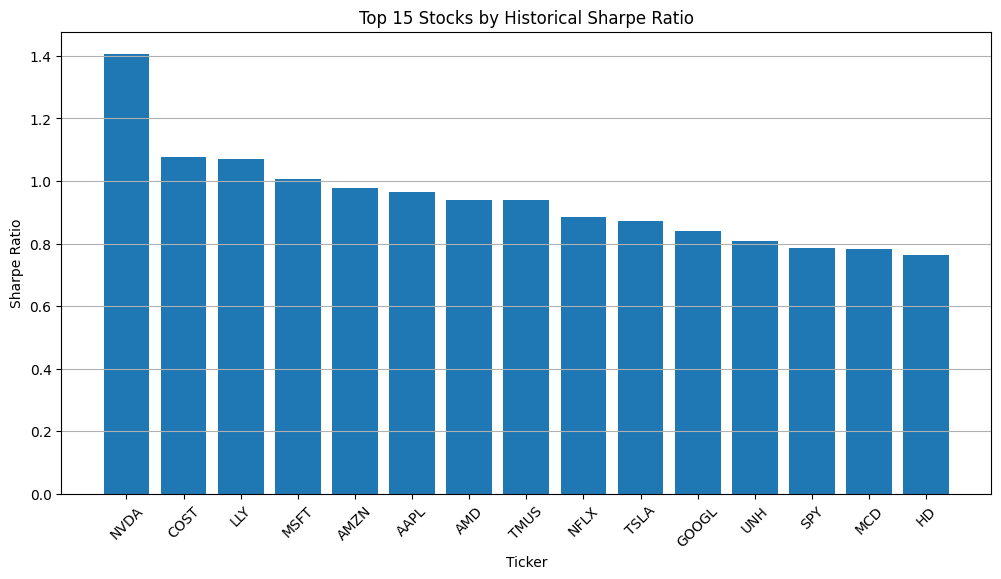

In [ ]:
# Plot top 15 stocks by Sharpe Ratio

top_15_sharpe = risk_return_table.head(15)

plt.figure(figsize=(12, 6))
plt.bar(top_15_sharpe.index, top_15_sharpe["Sharpe Ratio"])

plt.title("Top 15 Stocks by Historical Sharpe Ratio")
plt.xlabel("Ticker")
plt.ylabel("Sharpe Ratio")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.savefig("plots/top_15_sharpe_ratio.png", dpi=300, bbox_inches="tight")
plt.show()

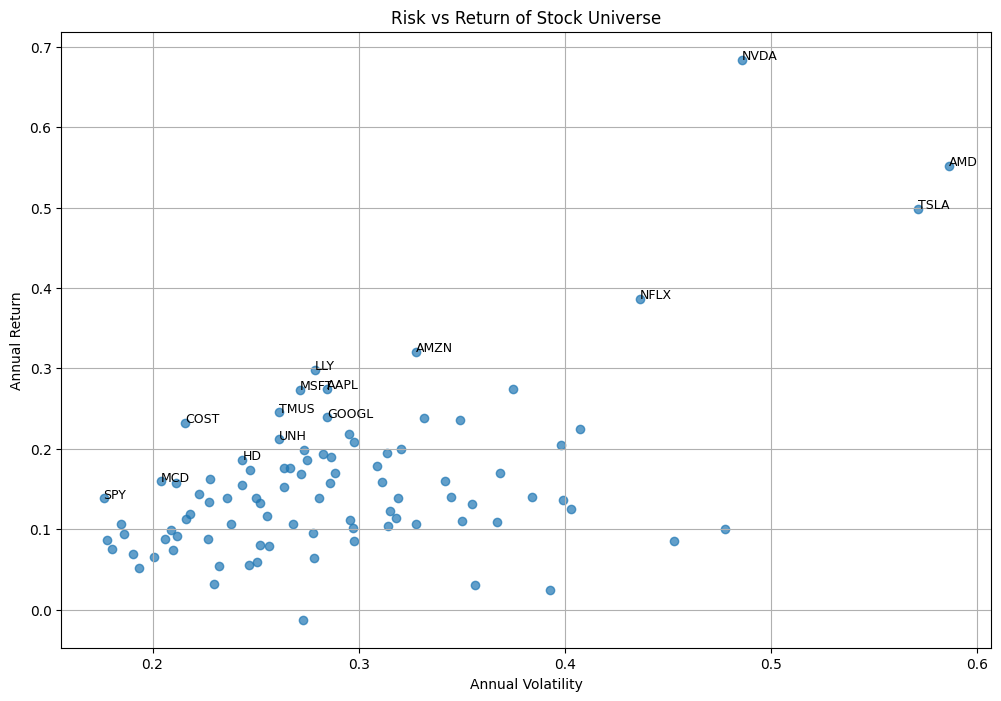

In [ ]:
# Risk-return scatter plot

plt.figure(figsize=(12, 8))

plt.scatter(
    risk_return_table["Annual Volatility"],
    risk_return_table["Annual Return"],
    alpha=0.7
)

# Label only top 15 Sharpe stocks to avoid clutter
for ticker in top_15_sharpe.index:
    plt.text(
        risk_return_table.loc[ticker, "Annual Volatility"],
        risk_return_table.loc[ticker, "Annual Return"],
        ticker,
        fontsize=9
    )

plt.title("Risk vs Return of Stock Universe")
plt.xlabel("Annual Volatility")
plt.ylabel("Annual Return")
plt.grid(True)

plt.savefig("plots/risk_vs_return_large.png", dpi=300, bbox_inches="tight")
plt.show()

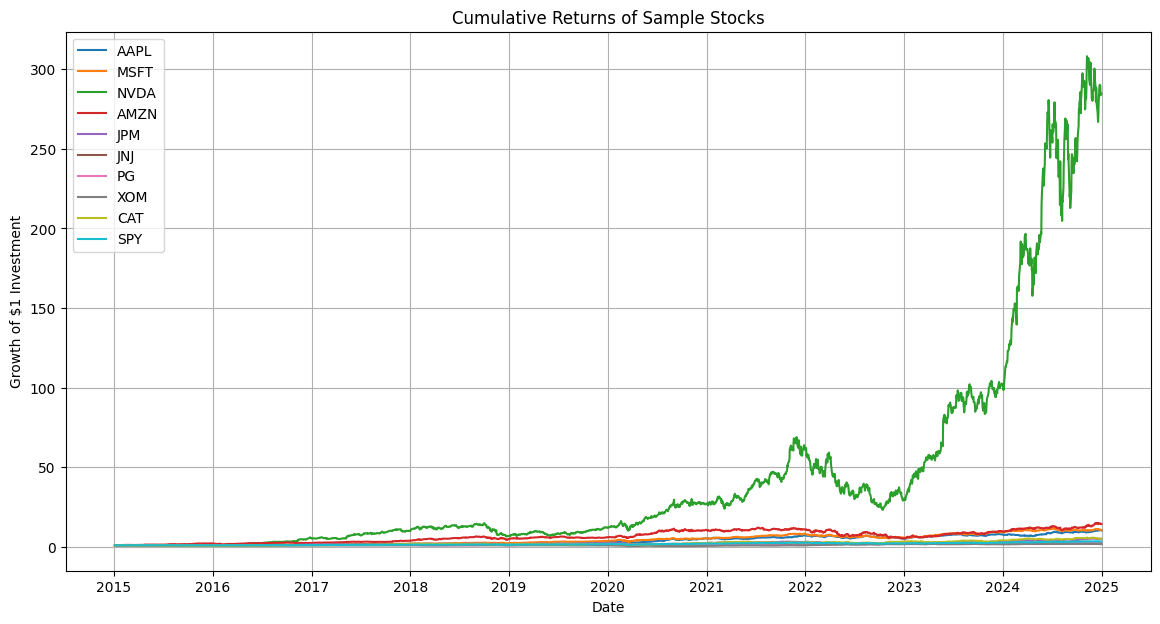

In [ ]:
# Plot cumulative returns for sample stocks

sample_tickers = ["AAPL", "MSFT", "NVDA", "AMZN", "JPM", "JNJ", "PG", "XOM", "CAT", "SPY"]

# Keep only tickers that exist in the dataset
sample_tickers = [ticker for ticker in sample_tickers if ticker in simple_returns.columns]

cumulative_returns = (1 + simple_returns[sample_tickers]).cumprod()

plt.figure(figsize=(14, 7))

for ticker in sample_tickers:
    plt.plot(cumulative_returns.index, cumulative_returns[ticker], label=ticker)

plt.title("Cumulative Returns of Sample Stocks")
plt.xlabel("Date")
plt.ylabel("Growth of $1 Investment")
plt.legend()
plt.grid(True)

plt.savefig("plots/sample_cumulative_returns_large.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
summary_stats = pd.DataFrame({
    "Metric": [
        "Number of Stocks",
        "Number of Trading Days",
        "Start Date",
        "End Date",
        "Average Annual Return",
        "Average Annual Volatility",
        "Average Sharpe Ratio"
    ],
    "Value": [
        prices.shape[1],
        prices.shape[0],
        prices.index.min().strftime("%Y-%m-%d"),
        prices.index.max().strftime("%Y-%m-%d"),
        round(risk_return_table["Annual Return"].mean(), 4),
        round(risk_return_table["Annual Volatility"].mean(), 4),
        round(risk_return_table["Sharpe Ratio"].mean(), 4)
    ]
})

summary_stats.to_csv("data/dataset_summary.csv", index=False)

summary_stats

,Metric,Value
0,Number of Stocks,93
1,Number of Trading Days,2515
2,Start Date,2015-01-02
3,End Date,2024-12-30
4,Average Annual Return,0.1579
5,Average Annual Volatility,0.2915
6,Average Sharpe Ratio,0.5352
